In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples, get_wasserstein_dist, get_delta_R_neighbors_numba_exact, get_delta_R_neighbors_kdtree
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d
from helpers.material_map import apply_material_map_hybrid


plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

collections = [
    "InnerTrackerBarrelCollection",
  # "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
 #   "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
  #  "VertexEndcapCollection",
]


feature_order_endcap = [0, 4, 1, 2, 3,  5, 6]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_barrel =[0, 4, 1, 2, 3,  5, 6] #[0, 4, 2, 3, 1,  5, 6]
feature_indices_dict_barrel = {
    "r":4,
    "phi": 2,
    "z":3,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "M_8192_cond2"
NUM_COND_INPUTS = 3
SEED = 8



FEATURES = "xy"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [3]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}
feature_labels_dict = {}

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    with open(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/results.txt") as ifile:
        aucs[col_name]=  ifile.readlines()[-1]
    feature_labels_dict[col_name] = feature_labels


    if FEATURES == "xy":

        r_data = np.sqrt(all_data_dir[col_name][:,2]**2 + all_data_dir[col_name][:,3]**2)
        phi_data = np.arctan2(all_data_dir[col_name][:,3], all_data_dir[col_name][:,2])

        r_samples = np.sqrt(all_samples_dir[col_name][:,2]**2 + all_samples_dir[col_name][:,3]**2)
        phi_samples = np.arctan2(all_samples_dir[col_name][:,3], all_samples_dir[col_name][:,2])

        if "Barrel" in col_name:
            # e t phi z r
            all_data_dir[col_name][:,2] = phi_data
            all_data_dir[col_name][:,3] = all_data_dir[col_name][:,4]
            all_data_dir[col_name][:,4] = r_data
            feature_labels_dict[col_name] = feature_labels = ["log($E$) [Gev]", "$t$ [s]", "$\phi$", "$z$",  "$r$", "side", "layer"]


            all_samples_dir[col_name][:,2] = phi_samples
            all_samples_dir[col_name][:,3] = all_samples_dir[col_name][:,4]
            all_samples_dir[col_name][:,4] = r_samples

        elif "Endcap" in col_name:
            # e t r phi z
            all_data_dir[col_name][:,2] = r_data
            all_data_dir[col_name][:,3] = phi_data
            feature_labels_dict[col_name] = feature_labels = ["log($E$) [Gev]", "$t$ [s]", "$r$", "$\phi$", "$z$", "side", "layer"]

            all_samples_dir[col_name][:,2] = r_samples
            all_samples_dir[col_name][:,3] = phi_samples
            

   



    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(all_data_dir[col_name].shape[1])}
    
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_325296/1008191765.py:33: SyntaxWarning: invalid escape sequence '\p'
  feature_labels_dict[col_name] = feature_labels = ["log($E$) [Gev]", "$t$ [s]", "$\phi$", "$z$",  "$r$", "side", "layer"]
/tmp/ipykernel_325296/1008191765.py:44: SyntaxWarning: invalid escape sequence '\p'
  feature_labels_dict[col_name] = feature_labels = ["log($E$) [Gev]", "$t$ [s]", "$r$", "$\phi$", "$z$", "side", "layer"]


In [4]:
for key in aucs.keys():
    print(f"{key}: {aucs[key]}")    

InnerTrackerBarrelCollection: auc 0.6308803283423646 pm 0.00028505829715229396. best epoch [999, 999, 999, 999, 999] of 1000.

OuterTrackerBarrelCollection: auc 0.5975480900927161 pm 0.00026858011160500213. best epoch [998, 999, 999, 999, 998] of 1000.

VertexBarrelCollection: auc 0.6708332442108939 pm 0.000199764836617178. best epoch [999, 999, 998, 996, 999] of 1000.



In [5]:
def make_2d_plots(data_array, labels):


    fig, ax = plt.subplots(1, len(data_array), figsize = (10*len(data_array), 10))

    

    for i, key in enumerate(data_array.keys()):

        coord0_lim = np.min(data_array["data"][0]), np.max(data_array["data"][0])
        coord1_lim = np.min(data_array["data"][1]), np.max(data_array["data"][1])
            
        ax[i].scatter(data_array[key][0], data_array[key][1], s = 0.001)
        ax[i].set_xlim(coord0_lim)
        ax[i].set_ylim(coord1_lim)
        ax[i].set_xlabel(labels[0])
        ax[i].set_ylabel(labels[1])
        ax[i].set_title(key)

    plt.show()


    

In [6]:
# for col_name in collections:

#     print(col_name)

#     plot_hists_1d(
#         {"data": all_data_dir[col_name], "samples": all_samples_dir[col_name]},
#         bins_dict[col_name],
#         log_dims=log_vars,
#         labels=feature_labels_dict[col_name]
#     )
#     plt.savefig(f"figures/{col_name}_1d.png")

#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         )
#     }

#     make_2d_plots(loc_array, ["x", "y"])

#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         )
#     }

#     make_2d_plots(loc_array, ["r", "z"])

In [7]:
"""
for col_name in collections:
    fig_samp, axes_samp = plot_corner_hist_2d(
       all_samples_dir[col_name],
        feature_labels=feature_labels,
        bins_dict=bins_dict[col_name],
        log_dims=log_vars,
        title= "flow_samples",
    )
    plt.savefig(f"figures/{col_name}_2d.png")
"""


'\nfor col_name in collections:\n    fig_samp, axes_samp = plot_corner_hist_2d(\n       all_samples_dir[col_name],\n        feature_labels=feature_labels,\n        bins_dict=bins_dict[col_name],\n        log_dims=log_vars,\n        title= "flow_samples",\n    )\n    plt.savefig(f"figures/{col_name}_2d.png")\n'

In [8]:


#material_map = build_material_map_2Dphi(all_data_dir, feature_indices_dict, N_BINS= 320)

In [9]:

# for col_name in collections:

#     print(col_name)
#     mask = apply_material_map_hybrid(all_samples_dir, None, col_name, feature_indices_dict)
    
#     print(f"{100*sum(mask)/len(mask)}% of samples pass ({sum(mask)})")
#     plot_hists_1d({
#         "data":all_data_dir[col_name], 
#          "masked samples": all_samples_dir[col_name][mask],
#         "unmasked samples":  all_samples_dir[col_name]
#     }, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)
#     plt.savefig(f"figures/{col_name}_1d.png")


    
#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         ),
#         "masked samples": (
#             all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["phi"]]),
#             all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["phi"]])
#         )
#     }

#     make_2d_plots(loc_array, ["x", "y"])

#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         ),
#         "masked samples": (
#             all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["r"]],
#             all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["z"]]
#         )
#     }

#     make_2d_plots(loc_array, ["r", "z"])

In [10]:
num_BDTs = 1

In [11]:
def compute_feature_bdt_scores(data, samples, device="cuda"):
    """
    Train a 1D BDT per feature to discriminate data vs samples.
    Returns dict: feature_index -> (auc_mean, auc_std)
    """
    results = {}

    for i in range(data.shape[1]):
        data_feat = data[:, i].reshape(-1, 1)
        samples_feat = samples[:, i].reshape(-1, 1)

        auc_mean, auc_std, *_ = discriminate_data_from_samples(
            data_feat,
            samples_feat,
            num_BDTs,
            "configs/bdt.yml",
            model_type="bdt",
            plot_losses=False,
            device=device,
            val_size=0.25,
            plot_dir="."
        )

        results[i] = (auc_mean, auc_std)
        print(f"Feature {i} BDT AUC: {auc_mean:.4f} ± {auc_std:.4f}")

    return results

In [12]:
import torch



device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)

def run_eval_suite_BDTs(data, samples_dict, bins, plot_suffix=""):

    print(f"Len data: {len(data)}")

    loc_scores_list = []
    single_bdt_results = {key:{} for key in samples_dict.keys()}

    scores_results = {key:{} for key in samples_dict.keys()}
    X_plot_results = {key:{} for key in samples_dict.keys()}

    for sample_key in samples_dict.keys():
        loc_samples = samples_dict[sample_key]
        print(f"Len samples {sample_key}: {len(loc_samples)}")


        # Per-feature BDT evaluation
        print("\nPer-feature BDT performance:")
        #bdt_feature_results = compute_feature_bdt_scores(data, loc_samples, device=device)

        #single_bdt_results[sample_key] = bdt_feature_results
        # BDT
        auc_mean, auc_std, best_epoch_list, max_epochs, bdt_list, samples_test, loc_scores = discriminate_data_from_samples(
                                                data,
                                                loc_samples,
                                                num_BDTs,
                                                "configs/bdt.yml",
                                                model_type="bdt",
                                                plot_losses=False,
                                                device="cuda",
                                                val_size = 0.25, 
                                                plot_dir="."
                                            )
    
        print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
        loc_scores_list.append(loc_scores)
        scores_results[sample_key] = loc_scores
        X_plot_results[sample_key] = samples_test

        X_plot = {"samples":  samples_test}
        percentiles = [70, 80, 90, 99]
        for p in percentiles:
            X_plot[f"samples, top {p}%"] =  samples_test[loc_scores >= np.percentile(loc_scores, p)]
    
        plot_hists_1d({"data":data, **X_plot}, bins, log_dims=log_vars, labels=feature_labels)

    
        
    plt.figure()
    for i, sample_key in enumerate(samples_dict.keys()):
              
        plt.hist(loc_scores_list[i], bins = np.linspace(0, 1, 100), histtype = "step", density = True, label = sample_key)
    plt.yscale("log")
    plt.legend()
    plt.xlabel("scores")
    plt.ylabel("Density")
    plt.show()


    return single_bdt_results, scores_results, X_plot_results
        


def run_eval_suite_R(data, samples_dict, R_values, NUM_BINS, plot_suffix=""):

        print(f"Len data: {len(data)}")

        R_values_dict_samples = {R:[] for R in R_values}
        R_values_dict_data = {R:0 for R in R_values}
        R_values_bins = {R:0 for R in R_values}

        for sample_key in samples_dict.keys():
            loc_samples = samples_dict[sample_key]
            print(f"Len samples {sample_key}: {len(loc_samples)}")

            # Clustering
            for R in R_values:
                neighbor_counts_data = get_delta_R_neighbors_kdtree(data, R, FEATURES)
                neighbor_counts_flow = get_delta_R_neighbors_kdtree(loc_samples, R, FEATURES)
            
                max_val = np.max(neighbor_counts_data)
            
                bin_spacing = int(max_val/NUM_BINS) + 1

                R_values_dict_data[R] = neighbor_counts_data
                R_values_dict_samples[R].append(neighbor_counts_flow)
                R_values_bins[R] = max_val, bin_spacing
            

        for R in R_values:
            plt.figure()
            
            for i, sample_key in enumerate(samples_dict.keys()):
                
                plt.hist(R_values_dict_samples[R][i], bins=np.arange(0, R_values_bins[R][0], R_values_bins[R][1]), histtype = "step", label = sample_key)
            plt.hist(R_values_dict_data[R], bins=np.arange(0, R_values_bins[R][0], R_values_bins[R][1]), histtype = "step", label = "data")
            plt.legend()
            plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")
            plt.ylabel("Count")
            plt.savefig(f"figures/deltaR{R}{plot_suffix}.png")
            plt.show()


        
        
        




<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_325296/939099694.py:41: SyntaxWarning: invalid escape sequence '\p'
  print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
/tmp/ipykernel_325296/939099694.py:104: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")


Using device: cuda


Analyzing InnerTrackerBarrelCollection...
1668891
(3926196, 7) (3926196, 7) (3926196,)
Len data: 1000000
Len samples unmasked: 1000000

Per-feature BDT performance:
auc 0.628792631904 \pm 0.0. best epoch [999] of 1000.

Len samples masked: 1000000

Per-feature BDT performance:
auc 0.7378583160000001 \pm 0.0. best epoch [999] of 1000.



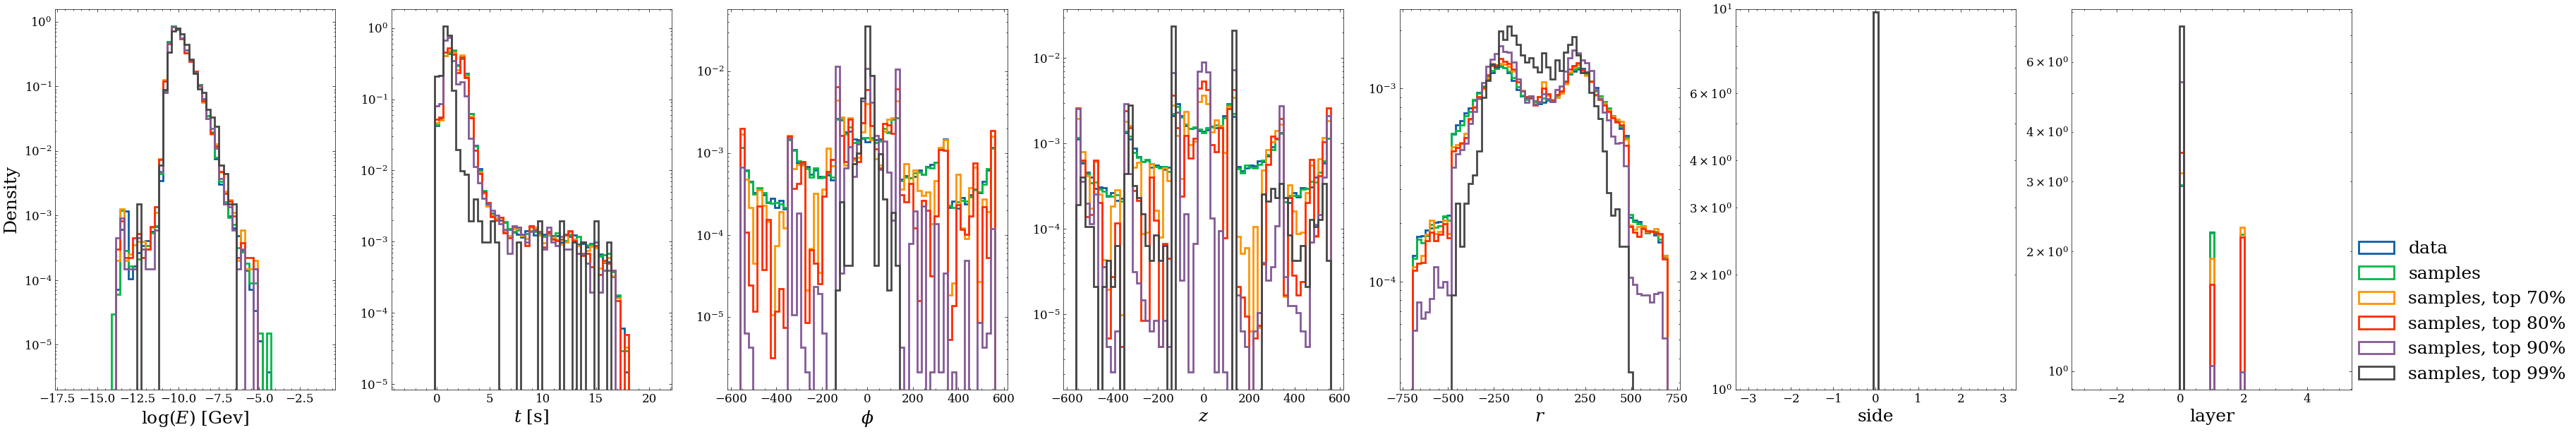

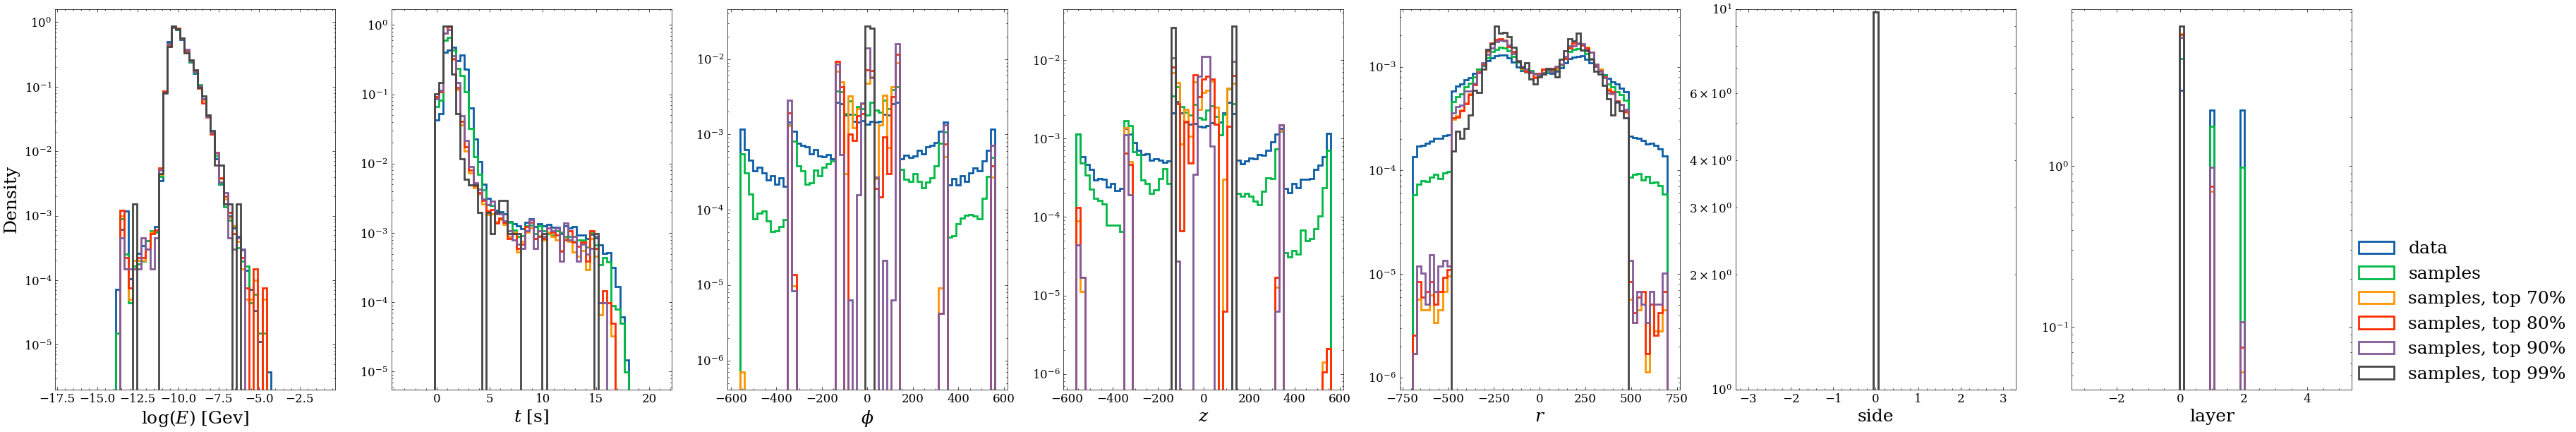

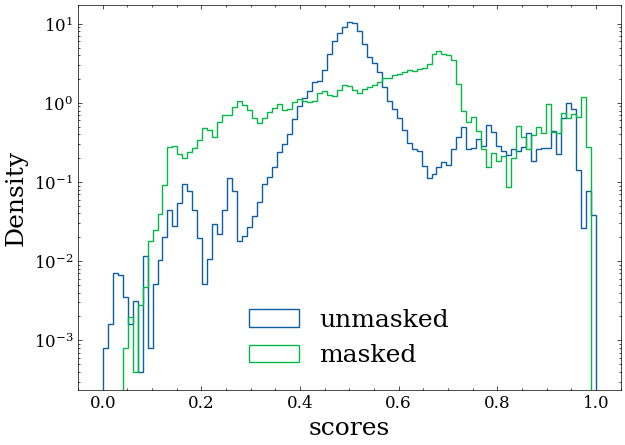

Analyzing OuterTrackerBarrelCollection...
161677
(3280678, 7) (3280678, 7) (3280678,)


ValueError: Cannot take a larger sample than population when 'replace=False'

In [13]:
single_bdt_results, all_scores, all_plot = {}, {}, {}

for col_name in collections:

    print(f"Analyzing {col_name}...")

    
    mask = apply_material_map_hybrid(all_samples_dir, None, col_name, feature_indices_dict)
    N = 1_000_000
    print(np.sum(mask))


    


    if "Barrel" in col_name:
        # e t phi z r to e t x y z
    
        data_x = all_data_dir[col_name][:,4]* np.cos(all_data_dir[col_name][:,2])
        data_y = all_data_dir[col_name][:,4]* np.sin(all_data_dir[col_name][:,2])
    
        all_data_dir[col_name][:,4] = all_data_dir[col_name][:,3]
        all_data_dir[col_name][:,2] = data_x
        all_data_dir[col_name][:,3] = data_y
        
    
        samples_x = all_samples_dir[col_name][:,4]* np.cos(all_samples_dir[col_name][:,2])
        samples_y = all_samples_dir[col_name][:,4]* np.sin(all_samples_dir[col_name][:,2])
        
    
    
        all_samples_dir[col_name][:,4] = all_samples_dir[col_name][:,3]
        all_samples_dir[col_name][:,2] = samples_x
        all_samples_dir[col_name][:,3] = samples_y
    
    elif "Endcap" in col_name:
        # e t r phi z  to e t x y z
    
        data_x = all_data_dir[col_name][:,2]* np.cos(all_data_dir[col_name][:,3])
        data_y = all_data_dir[col_name][:,2]* np.sin(all_data_dir[col_name][:,3])
    
        
        all_data_dir[col_name][:,2] = data_x
        all_data_dir[col_name][:,3] = data_y
    
        data_x = all_samples_dir[col_name][:,2]* np.cos(all_samples_dir[col_name][:,3])
        data_y = all_samples_dir[col_name][:,2]* np.sin(all_samples_dir[col_name][:,3])
    
        
        all_samples_dir[col_name][:,2] = data_x
        all_samples_dir[col_name][:,3] = data_y
    
    

     
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 
    
    indices_1 = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    indices_2 = np.random.choice(all_samples_dir[col_name].shape[0], size=N, replace=False)
    

    print(all_data_dir[col_name].shape, all_samples_dir[col_name].shape, mask.shape)

    indices_3 = np.random.choice(all_samples_dir[col_name][mask].shape[0], size=N, replace=False)

    tmp = run_eval_suite_BDTs(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, bins_dict[col_name],
                       
                      plot_suffix=f"_{col_name}")

    single_bdt_results[col_name] = tmp[0]
    all_scores[col_name] = tmp[1]
    all_plot[col_name] = tmp[2]


  #  run_eval_suite_R(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, [0.1, 0.2, 0.4],  100, plot_suffix="")
#
    


In [ ]:

plt.figure()
for i, col_name in enumerate(single_bdt_results.keys()):
    if "Endcap" in col_name:
        for key in single_bdt_results[col_name].keys():
            x_vals = single_bdt_results[col_name][key].keys()
            
            res = [single_bdt_results[col_name][key][x][0] for x in x_vals]
            res_gauss = [single_bdt_results[col_name][key][x][1] for x in x_vals]
            if key == "masked":
                plt.scatter(x_vals, res, color = f"C{i}", label = f"{col_name}, masked", marker="o", s=100)
            elif key == "unmasked":
                plt.scatter(x_vals, res, edgecolor = f"C{i}", label = f"{col_name}, unmasked", marker="o", s=100, facecolor="none")
plt.legend(loc=(1,0))
plt.xticks([0, 1, 2, 3, 4, 5, 6], labels = feature_labels_dict[col_name], rotation = 45)
plt.xlabel("feature")

plt.ylabel("ROC AUC")
plt.show()

In [ ]:
print(feature_indices_dict)

In [ ]:
for col_name in single_bdt_results.keys():
    if "Barrel" in col_name:


        plt.figure(figsize = (10, 10))
        

        p = 80

        passes =  np.array(all_scores[col_name]["unmasked"] >= np.percentile(all_scores[col_name]["unmasked"], p))

        x = all_plot[col_name]["unmasked"][:,feature_indices_dict[col_name]["r"]]*np.cos(all_plot[col_name]["unmasked"][:,feature_indices_dict[col_name]["phi"]])
        y = all_plot[col_name]["unmasked"][:,feature_indices_dict[col_name]["r"]]*np.sin(all_plot[col_name]["unmasked"][:,feature_indices_dict[col_name]["phi"]])

        

            
        plt.scatter(x[passes], y[passes], color = "red", s = 0.01)
        plt.scatter(x[~passes], y[~passes], color = "green", s = 0.01)

        plt.xlim(0, 130)
        plt.ylim(0, 130)

        plt.show()
        
      

In [ ]:

bb = np.linspace(522.84, 522.86, 1000)

plt.figure()
plt.hist(all_data_dir[col_name][:,feature_indices_dict["z"]], bins = bb, density = True, label = "data", histtype = "stepfilled")


for p in [99]:
    tmp_masked =  all_plot[col_name]["masked"][all_scores[col_name]["masked"] >= np.percentile(all_scores[col_name]["masked"], p)]
    tmp_unmasked =  all_plot[col_name]["unmasked"][all_scores[col_name]["unmasked"] >= np.percentile(all_scores[col_name]["unmasked"], p)]

    
    plt.hist(tmp_unmasked[:,feature_indices_dict["z"]], bins = bb, histtype = "step", density = True, label = "unmasked")
    
    plt.hist(tmp_masked[:,feature_indices_dict["z"]], bins = bb, histtype = "step", density = True, label = "masked")
plt.legend()
plt.yscale("log")
plt.show()

In [ ]:
bins = 1000
for col_name in collections:

    print(col_name)

    plt.figure(figsize = (10, 10))

    plt.hist2d(all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.cos(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]]), 
               all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.sin(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]]), 
               bins=(bins,bins),
              norm="log",)
    plt.show()
   